# Machine learning approach for Western vs Non-western

# Feature Selection Methods for Microbiome ML

After preprocessing, three families of feature selection methods are commonly applied.
Each involves different trade-offs between speed, accuracy, and scalability.


## 1. Filter Methods

**How it works:** Rank features using statistical metrics (e.g., correlation, ANOVA) — no model needed.

**Pros:**
- Fast and computationally cheap
- Scales well to high-dimensional data

**Cons:**
- May select redundant features
- Correlation-based methods may suffer from false positives when correlation is driven by sparse features
- May select only one feature from a correlated pair → suboptimal selection


## 2. Wrapper Methods

**How it works:** Use a predictive model to evaluate feature subsets by performance
(e.g., Recursive Feature Elimination, SES).

**Pros:**
- Better captures complex interactions between features
- Performs better than filter methods in the presence of redundancy, sparsity, or low sample size

**Cons:**
- Computationally intensive
- May not scale well to high-dimensional data


## 3. Embedded Methods

**How it works:** Feature selection happens *inside* model training — built in, not bolted on
(e.g., LASSO, Elastic Net) (Tibshirani, 1996).

**Pros:**
- Perform both feature selection and regularization during model training
- Well-suited for high-dimensional, sparse data
- Handle low sample size relatively well (Tibshirani, 1996)
- Can identify a small number of highly relevant features that capture underlying patterns

## Quick Comparison

| Method   | Speed    | Handles sparsity | Captures interactions |
|----------|----------|------------------|-----------------------|
| Filter   | Fast     | Weak             | No                    |
| Wrapper  | Slow     | Good             | Yes                   |
| Embedded | Moderate | Excellent        | Partial               |

After feature selection, a model should be chosen. There are linear models, which are easier to interpret. However, they could underperform on complex data. 
Nonlinear methods like random forest, SVMs and gradient boosting provide higher accuracy based on the paper. 

In [35]:
#IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_validate
from sklearn.inspection import partial_dependence
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler


## Categorizing

The paper mentions variance filtering, which will be done here. Features which have a close zero variance don't contribute to the model and need to be deleted.

In [36]:
# Load the data
df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")

# Lifestyle mapping
lifestyle_map = {
    'USA': 'Developed', 'UK': 'Developed', 'Germany': 'Developed', 
    'France': 'Developed', 'Spain': 'Developed', 'Italy': 'Developed', 
    'Austria': 'Developed', 'Denmark': 'Developed', 'Finland': 'Developed', 
    'Luxemburg': 'Developed', 'Sweden': 'Developed', 'Japan': 'Developed',

    'India': 'Developing', 'Thailand': 'Developing', 
    'Peru': 'Developing', 'Fiji': 'Developing', 'Mongolia': 'Developing',
    'Tanzania': 'Developing', 'Madagascar': 'Developing'
}

df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Isolate features and target (bmi, age,... excluded)
X = df[[col for col in df.columns if col.startswith('msp')]]
y = df['Lifestyle'].map({'Developing': 1, 'Developed': 0})

groups = df['Geography']  # This maps each sample to its cohort/country

# Drop NAs just in case
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

groups = groups.loc[valid_indices]  # <--- ADD THIS LINE

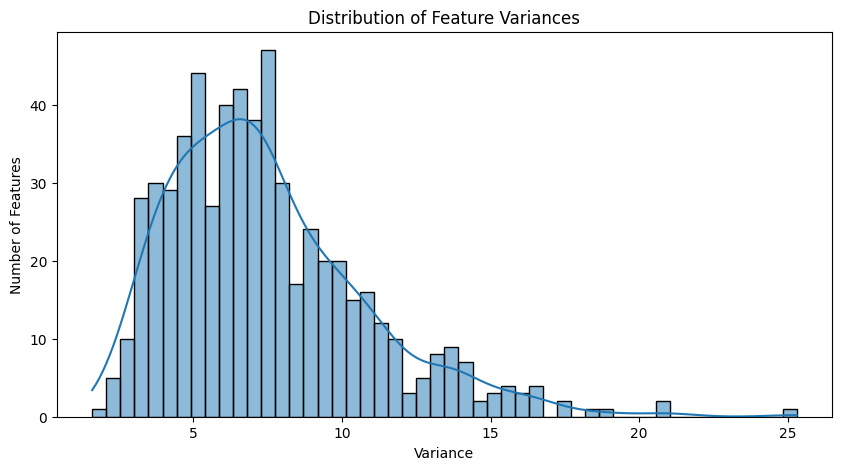

In [37]:
# Calculate the variance of each feature in X
variances = X.var()

# Plot the distribution of variances to see it visually
plt.figure(figsize=(10, 5))
sns.histplot(variances, bins=50, kde=True)
plt.title('Distribution of Feature Variances')
plt.xlabel('Variance')
plt.ylabel('Number of Features')
plt.show()


As seen in the plot above, there are alot of feature which are near zero variance. This needs to be taken care of in the model

## Random Forest

"**Random Forests exhibited the highest predictive performance, followed by Ridge Logistic Regression**" [Papoutsoglou et al (2023)](../Papers/Machine%20learning/Papoutsoglou.pdf). 
This ensemble method excels at capturing non-linear microbial interactions within high-dimensional,  sparse datasets. It provides the necessary robustness to mitigate overfitting and manage the high variance inherent in our multi-country cohorts.

## Pipeline Steps


### 1. Variance Threshold
Acts as a noise filter — removes microbial species that barely change from person to person. If a microbe has very low variance, it carries too little information to distinguish Western from Non-Western lifestyles.


### 2. LASSO (Feature Selection)
Works as a minimalist filter. In microbiome research you often have thousands of species but only a few hundred samples. LASSO applies a mathematical penalty to model complexity, forcing the least helpful or redundant features to zero.


### 3. Random Forest
A non-linear decision-maker, complementing LASSO's linear approach. Builds hundreds of individual decision trees and averages their results. Effective for microbiome data because it captures complex, non-linear relationships where species interact in many different ways.

### 4. Nested Cross-Validation
Prevents models from "cheating" by seeing patterns in the data they are supposed to be tested on. Uses two loops:

- **Inner loop** — tries different settings to find the best model configuration.
- **Outer loop** — tests that best model on data it has never seen, giving an unbiased
  accuracy score.


### 5. StratifiedGroupKFold
Guards against technical batch effects by holding out entire countries from training, proving the model can generalise. For example, with 10 countries and 5 folds:

- **Grouping** — samples from the same country or lab never appear in both training and
  test sets, preventing data leakage.
- **Stratified** — every fold contains a balanced mix of Western and Non-Western samples.

This forces the model to learn a biological signature that works across the globe, not just the technical quirks of a single lab.

In [38]:
# Define the Pipeline
pipeline = Pipeline([
    ('var_filter', VarianceThreshold()), 
    ('lasso_selector', SelectFromModel(LogisticRegression(l1_ratio=1, solver='liblinear', class_weight='balanced', random_state=42))),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=1))
])

# Define Hyperparameter Space
param_grid = {
    'var_filter__threshold': [0, 0.0001, 0.001], 
    'lasso_selector__estimator__C': [0.1, 1.0, 10.0], 
    'rf__n_estimators': [100, 200, 300],        
    'rf__max_depth': [10, 20, None],
    'rf__max_features': ['sqrt', 'log2']          
}

# Setup Nested CV Structure
# Using GroupKFold to prevent the model from memorizing specific countries
inner_cv = StratifiedGroupKFold(n_splits=3)

rf_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid, 
    n_iter=10,           
    cv=inner_cv, 
    scoring='roc_auc', 
    n_jobs=-1,          
    random_state=42
)

outer_cv = StratifiedGroupKFold(n_splits=5)

# Execute Nested CV
metrics = ['roc_auc', 'f1', 'balanced_accuracy']

# THE FIX: Added to pass groups to the inner loop!
results = cross_validate(
    rf_search, 
    X, 
    y, 
    groups=groups, 
    cv=outer_cv, 
    scoring=metrics, 
    n_jobs=-1,
    params={'groups': groups} 
)


/var/folders/d3/491fzvvs5lg2864030mq9_lw0000gn/T/ipykernel_87083/3342719562.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_accuracy.values, y=country_accuracy.index, palette="mako", ax=ax2)


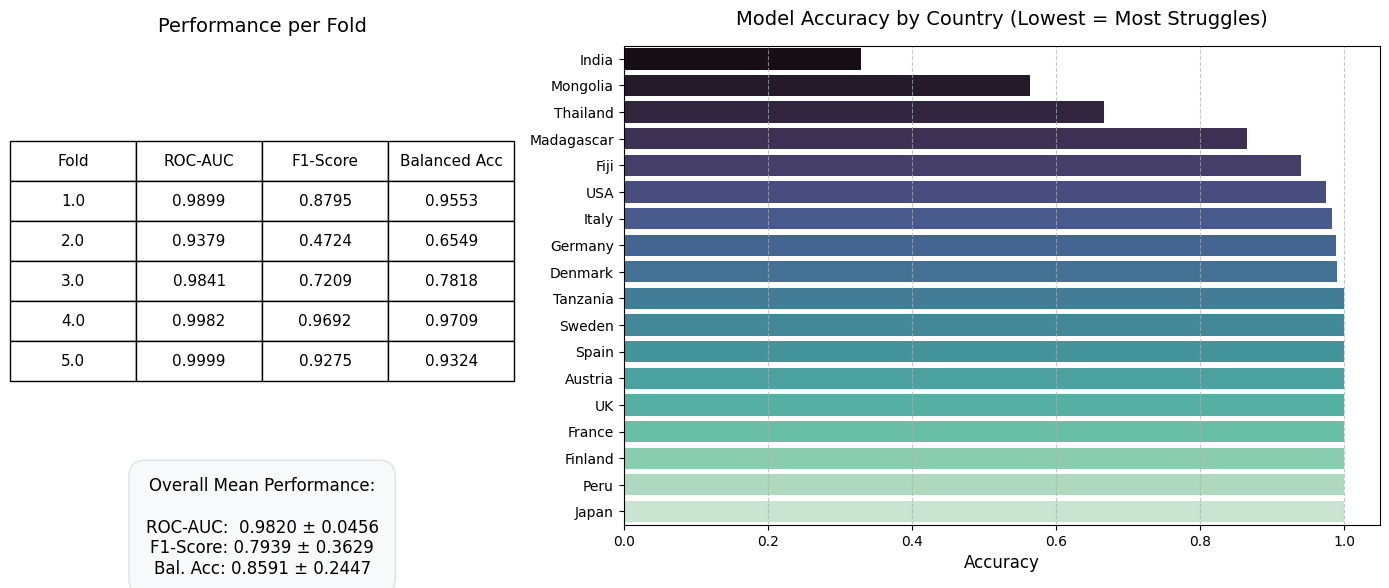

In [39]:
# 1. Generate out-of-fold predictions
y_pred = cross_val_predict(
    rf_search, 
    X, 
    y, 
    groups=groups, 
    cv=outer_cv, 
    n_jobs=-1,
    params={'groups': groups} 
)

# 2. Prepare the data
fold_summary = pd.DataFrame({
    'Fold': range(1, outer_cv.n_splits + 1),
    'ROC-AUC': results['test_roc_auc'],
    'F1-Score': results['test_f1'],
    'Balanced Acc': results['test_balanced_accuracy']
})

analysis_df = pd.DataFrame({'Country': groups, 'Correct': y == y_pred})
country_accuracy = analysis_df.groupby('Country')['Correct'].mean().sort_values()

# 3. Create a unified visual dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.5]})

# --- Left Panel: Metrics Table ---
ax1.axis('off')
ax1.set_title("Performance per Fold", fontsize=14, pad=10)

# Add the dataframe as a table
table = ax1.table(
    cellText=fold_summary.round(4).values,
    colLabels=fold_summary.columns,
    loc='center', 
    cellLoc='center',
    bbox=[0.0, 0.3, 1.0, 0.5]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Add overall summary text below the table
summary_text = (
    f"Overall Mean Performance:\n\n"
    f"ROC-AUC:  {results['test_roc_auc'].mean():.4f} ± {results['test_roc_auc'].std()*2:.4f}\n"
    f"F1-Score: {results['test_f1'].mean():.4f} ± {results['test_f1'].std()*2:.4f}\n"
    f"Bal. Acc: {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std()*2:.4f}"
)
ax1.text(0.5, 0.1, summary_text, ha='center', va='top', fontsize=12, 
         bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#dee2e6'))

# --- Right Panel: Country Accuracy Plot ---
sns.barplot(x=country_accuracy.values, y=country_accuracy.index, palette="mako", ax=ax2)
ax2.set_title("Model Accuracy by Country (Lowest = Most Struggles)", fontsize=14, pad=15)
ax2.set_xlabel("Accuracy", fontsize=12)
ax2.set_ylabel("") # Left blank to avoid redundant "Country" label
ax2.set_xlim(0, 1.05)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### High Averages
The model shows strong overall discriminative power (mean ROC-AUC ~0.95). However, while an 83% average balanced accuracy seems good, the massive variations (± 0.22 to ± 0.27) tell us to be cautious. These wide swings mean the model's performance fluctuates wildly depending on which specific population it is tested against. 

The bar chart explains why those folds swing a lot. The model is getting confused by a few specific countries.

- Japan: The model is failing here (Accuracy ~ 40%). Model is performing worse than a random coin flip
- USA & China: The model struggles less here with USA ~70% and China ~78%.


To understand why the model classifies Japan as Western, we look into the specific biological markes, given via feature importance in our random forest. With the question in mind:

**Which specific bacteria are driving these decisions?**



In [40]:
# # Final Fit & Feature Importance
nr_of_features = 20

rf_search.fit(X, y, groups=groups)
best_model = rf_search.best_estimator_

# # Extracting features that survived both Variance threshold AND LASSO
var_support = best_model.named_steps['var_filter'].get_support()
lasso_support = best_model.named_steps['lasso_selector'].get_support()

# # Map back to the original column names
features_after_var = X.columns[var_support]
final_features = features_after_var[lasso_support]

# Get Random Forest Importances
importances = best_model.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=final_features).sort_values(ascending=False).head(nr_of_features)

/var/folders/d3/491fzvvs5lg2864030mq9_lw0000gn/T/ipykernel_87083/3282261501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


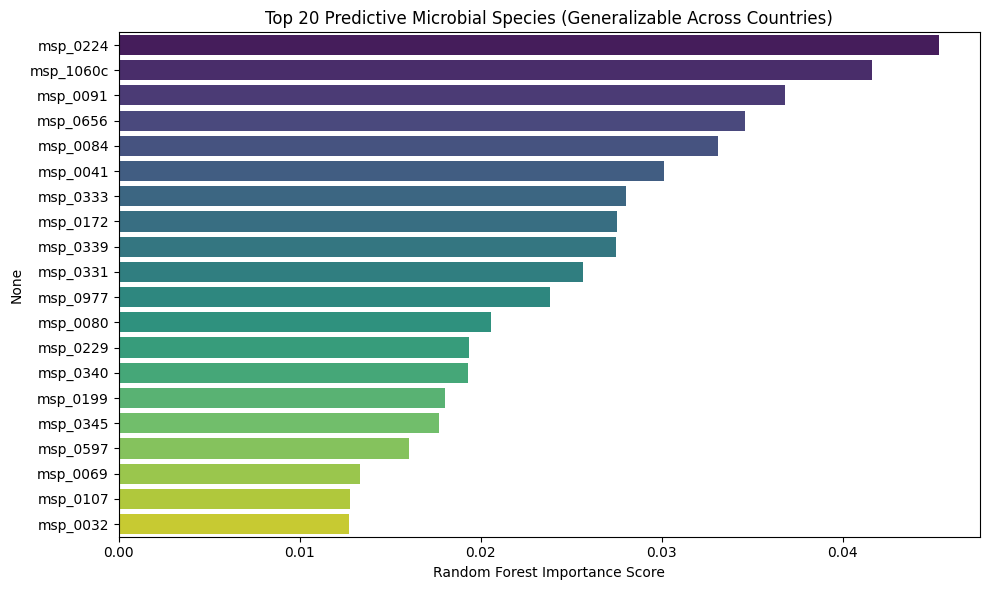

In [41]:
# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 20 Predictive Microbial Species (Generalizable Across Countries)')
plt.xlabel('Random Forest Importance Score')
plt.tight_layout()
plt.show()

### The  Extracting the XAI Math

It loops through your most important microbes and uses the partial_dependence function to calculate the exact background coordinates that normally draw the PDP lines.

### Calculating the Trend (trend_score)

It looks at the model's predicted probability of a sample being "Western" when the microbe is at its absolute lowest abundance, and subtracts that from the probability when the microbe is at its absolute highest abundance.

### Objective Categorization: 

If the probability goes up overall (score > 0.001), the microbe is mathematically categorized as a "Western" marker.

If the probability goes down (score < -0.001), it is a "Non-Western" marker.

In [42]:
direction_list = []

# Get all the top features you saved in 'feat_imp'
top_features = feat_imp.index.tolist()

for feature in top_features:
    # Extract the raw mathematical data behind the PDP plot
    pd_results = partial_dependence(best_model, X, features=[feature], grid_resolution=50)
    
    # y_values are the predicted probabilities of being "Western" (Class 1)
    y_values = pd_results['average'][0]
    
    # Calculate the overall trend (Probability at max abundance MINUS Probability at min abundance)
    trend_score = y_values[-1] - y_values[0]
    
    # Categorize it definitively 
    if trend_score > 0.001:
        category = "Western"
    elif trend_score < -0.001:
        category = "Non-Western"
    else:
        category = "Neutral / Complex"
        
    direction_list.append({
        'Microbe': feature,
        'RF_Importance': feat_imp[feature],
        'PDP_Trend_Score': trend_score,
        'Enriched_In': category
    })

# Convert to a clean DataFrame and display
final_biomarker_df = pd.DataFrame(direction_list).set_index('Microbe')

print("FINAL BIOMARKER TABLE (No Guessing Required)")
# Formatting the output to be readable
print(final_biomarker_df.to_string(formatters={
    'RF_Importance': '{:.4f}'.format,
    'PDP_Trend_Score': '{:.4f}'.format
}))

FINAL BIOMARKER TABLE (No Guessing Required)
          RF_Importance PDP_Trend_Score  Enriched_In
Microbe                                             
msp_0224         0.0453          0.0511      Western
msp_1060c        0.0416         -0.0651  Non-Western
msp_0091         0.0368          0.0490      Western
msp_0656         0.0346          0.0517      Western
msp_0084         0.0331          0.0382      Western
msp_0041         0.0301          0.0222      Western
msp_0333         0.0280          0.0281      Western
msp_0172         0.0275         -0.0282  Non-Western
msp_0339         0.0275          0.0513      Western
msp_0331         0.0257         -0.0438  Non-Western
msp_0977         0.0238         -0.0301  Non-Western
msp_0080         0.0206          0.0291      Western
msp_0229         0.0194          0.0254      Western
msp_0340         0.0193         -0.0301  Non-Western
msp_0199         0.0180          0.0143      Western
msp_0345         0.0177          0.0123      Western
m

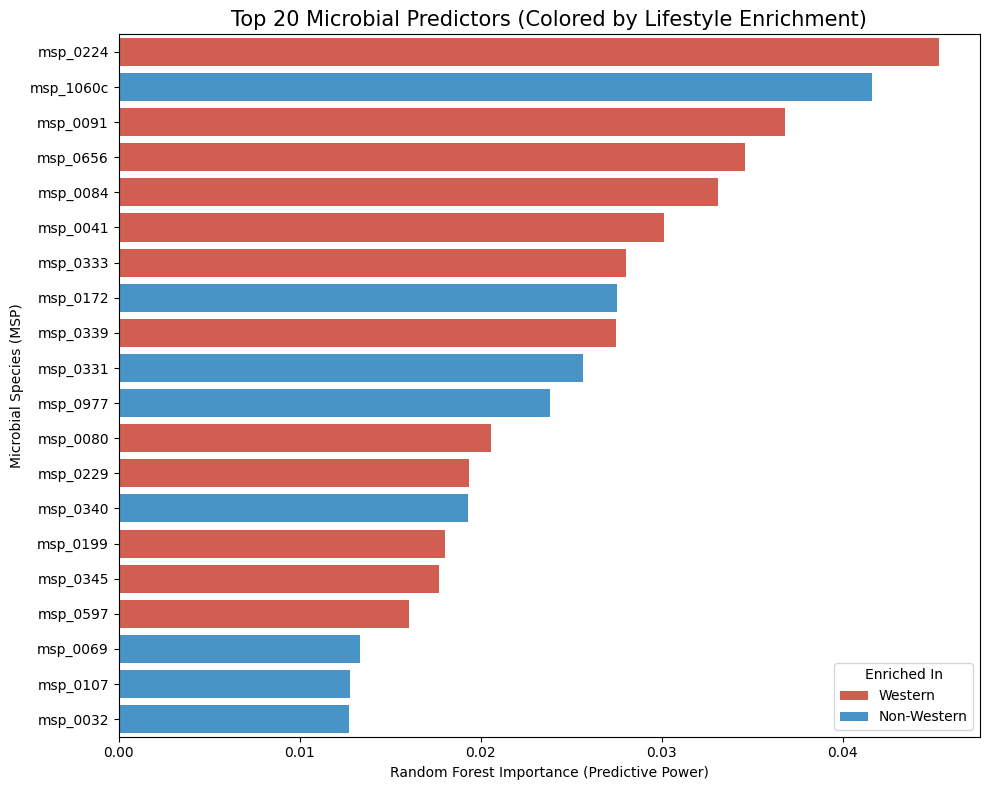

In [43]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=final_biomarker_df, 
    x='RF_Importance', 
    y=final_biomarker_df.index, 
    hue='Enriched_In',
    palette={'Western': '#e74c3c', 'Non-Western': '#3498db'},  # Red for Western, blue for Non-Western
    dodge=False  # Keep bars aligned on one line
)

plt.title('Top 20 Microbial Predictors (Colored by Lifestyle Enrichment)', fontsize=15)
plt.xlabel('Random Forest Importance (Predictive Power)')
plt.ylabel('Microbial Species (MSP)')
plt.legend(title='Enriched In', loc='lower right')
plt.tight_layout()
plt.show()

In [44]:
final_biomarker_df.to_csv("../results/biomarker_table_randomforest.csv", index=True)

# Logistic Regression

As a linear counterpart to our Random Forest, we implement a Logistic Regression model with L1 regularization (LASSO). The Random Forest excels at capturing complex, non-linear interactions between microbes, this model. In logistic regression, we force the algorithm to rely only on strictly linear relationships and actively penalizing redundant features, we can extract highly interpretable coefficients. This allows us to directly validate our core microbial signatures and objectively categorize them as "Western" or "Non-Western" drivers.

In [45]:
# Define the Logistic Regression Pipeline
# L1 penalty acts as the LASSO feature selector natively
lr_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('scaler', StandardScaler()), 
    ('lr', LogisticRegression(solver='saga', l1_ratio=1.0, class_weight='balanced', C=1.0, random_state=42, max_iter=1000))
])

groups_arr = groups.values

# Execute Cross-Validation
lr_results = cross_validate(
    lr_pipeline, 
    X, 
    y, 
    groups=groups_arr,
    cv=outer_cv, 
    scoring=['roc_auc', 'f1', 'balanced_accuracy'], 
    n_jobs=-1
)

# 3. Print Performance
print("Logistic Regression (L1) Performance")
print(f"Mean ROC-AUC:  {lr_results['test_roc_auc'].mean():.4f} ± {lr_results['test_roc_auc'].std()*2:.4f}")
print(f"Mean F1-Score: {lr_results['test_f1'].mean():.4f} ± {lr_results['test_f1'].std()*2:.4f}")
print(f"Bal. Accuracy: {lr_results['test_balanced_accuracy'].mean():.4f} ± {lr_results['test_balanced_accuracy'].std()*2:.4f}")

/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (L1) Performance
Mean ROC-AUC:  0.9915 ± 0.0234
Mean F1-Score: 0.8867 ± 0.1732
Bal. Accuracy: 0.9245 ± 0.1469


/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


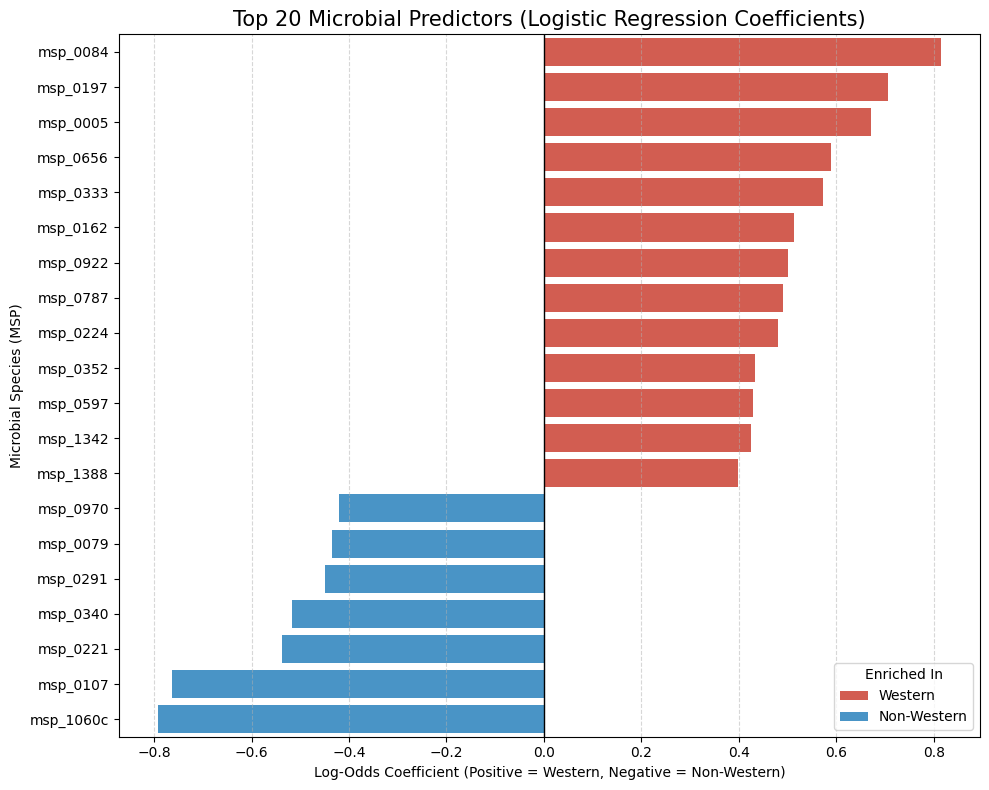

In [46]:
nr_of_features = 20

# Fit the pipeline on the ENTIRE dataset to extract the final coefficients
lr_pipeline.fit(X, y)

# Extract features that survived the variance filter
var_support = lr_pipeline.named_steps['var_filter'].get_support()
features_after_var = X.columns[var_support]

# Extract the coefficients from the Logistic Regression
coefficients = lr_pipeline.named_steps['lr'].coef_[0]

# Create a DataFrame for easy handling
coef_df = pd.DataFrame({
    'Microbe': features_after_var,
    'Coefficient': coefficients
})

# Filter out features that LASSO pushed to absolute zero
coef_df = coef_df[coef_df['Coefficient'] != 0]

# Sort by absolute magnitude to get the "Most Predictive" overall, then take top 20
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
top_20_lr = coef_df.sort_values(by='Abs_Coef', ascending=False).head(nr_of_features)

# Determine the category based on the sign for coloring
top_20_lr['Enriched_In'] = np.where(top_20_lr['Coefficient'] > 0, 'Western', 'Non-Western')

# --- PLOTTING ---
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_20_lr.sort_values(by='Coefficient', ascending=False), 
    x='Coefficient', 
    y='Microbe', 
    hue='Enriched_In',
    palette={'Western': '#e74c3c', 'Non-Western': '#3498db'},
    dodge=False
)

plt.axvline(0, color='black', linewidth=1)
plt.title('Top 20 Microbial Predictors (Logistic Regression Coefficients)', fontsize=15)
plt.xlabel('Log-Odds Coefficient (Positive = Western, Negative = Non-Western)')
plt.ylabel('Microbial Species (MSP)')
plt.legend(title='Enriched In', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [47]:
top_20_lr.to_csv("../results/biomarker_table_logistic_regression.csv", index=False)

In [48]:
import pandas as pd

# 1. Load the results from both models
try:
    rf_df = pd.read_csv('../results/biomarker_table_randomforest.csv')
    lr_df = pd.read_csv('../results/biomarker_table_logistic_regression.csv')
except FileNotFoundError as e:
    print(f"Error: Could not find the result files. Check your paths. {e}")
    exit()

# 2. Extract microbes and their enrichment categories into dictionaries
rf_dict = dict(zip(rf_df['Microbe'], rf_df['Enriched_In']))
lr_dict = dict(zip(lr_df['Microbe'], lr_df['Enriched_In']))

# 3. Find consensus microbes (those present in both models)
rf_microbes = set(rf_df['Microbe'])
lr_microbes = set(lr_df['Microbe'])
consensus_microbes = sorted(list(rf_microbes.intersection(lr_microbes)))

# 4. Categorize results
agreements = []
disagreements = []
comparison_data = []

for microbe in consensus_microbes:
    rf_val = rf_dict[microbe]
    lr_val = lr_dict[microbe]
    
    is_match = (rf_val == lr_val)
    status = "✓ AGREE" if is_match else "✗ DISAGREE"
    
    row = {
        'Microbe': microbe,
        'RF_Enriched': rf_val,
        'LR_Enriched': lr_val,
        'Agreement': status
    }
    comparison_data.append(row)
    
    if is_match:
        agreements.append(row)
    else:
        disagreements.append(row)

# 5. Convert to DataFrames for easy filtering/export
consensus_df = pd.DataFrame(comparison_data)
agree_df = pd.DataFrame(agreements)
disagree_df = pd.DataFrame(disagreements)

# --- FINAL OUTPUT ---

print("="*60)
print(f"ANALYSIS SUMMARY")
print("="*60)
print(f"Microbes shared by both models: {len(consensus_microbes)}")
print(f"Perfect Agreement:           {len(agree_df)}")
print(f"Disagreements:                {len(disagree_df)}")
print("-" * 60)

if not agree_df.empty:
    print("\n✅ MICROBES WITH AGREEMENT:")
    # Print a clean table using pandas string formatting
    print(agree_df[['Microbe', 'RF_Enriched']].to_string(index=False))

if not disagree_df.empty:
    print("\n❌ MICROBES WITH DISAGREEMENT:")
    print(disagree_df.to_string(index=False))

# 6. Optional: Save the comparison to a new CSV
# consensus_df.to_csv('../results/biomarker_model_comparison.csv', index=False)

ANALYSIS SUMMARY
Microbes shared by both models: 8
Perfect Agreement:           8
Disagreements:                0
------------------------------------------------------------

✅ MICROBES WITH AGREEMENT:
  Microbe RF_Enriched
 msp_0084     Western
 msp_0107 Non-Western
 msp_0224     Western
 msp_0333     Western
 msp_0340 Non-Western
 msp_0597     Western
 msp_0656     Western
msp_1060c Non-Western
